# 패키지 및 데이터

In [102]:
# ==================================================
# 기본 라이브러리
# ==================================================
import numpy as np
import seaborn as sb
import pandas as pd

from matplotlib import pyplot as plt
from pandas import DataFrame, concat



# ==================================================
# scikit-learn 공통
# ==================================================
from sklearn.pipeline import Pipeline

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    learning_curve,
)

from sklearn.preprocessing import StandardScaler


# ==================================================
# 분류 모델
# ==================================================
from sklearn.linear_model import (
    LogisticRegression,
    SGDClassifier,
)

from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    log_loss,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    roc_auc_score,
)

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
)


# ==================================================
# Boosting 계열
# ==================================================
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier


# ==================================================
# 사용자 정의 모듈
# ==================================================
from hossam import *


### 데이터

In [125]:
origin = pd.read_csv("kta-county-data-december-2025.csv")
origin.head()
origin.info()
origin.shape
origin.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94923 entries, 0 to 94922
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   RPT_DATE      94923 non-null  object 
 1   RPT_YR        94923 non-null  object 
 2   GEOGRAPHY     94923 non-null  object 
 3   SVC_DESC      94923 non-null  object 
 4   AMOUNT        62812 non-null  object 
 5   AMOUNT_ANNOT  32119 non-null  float64
 6   AMOUNT_TYPE   94903 non-null  object 
dtypes: float64(1), object(6)
memory usage: 5.1+ MB


,RPT_DATE,RPT_YR,GEOGRAPHY,SVC_DESC,AMOUNT,AMOUNT_ANNOT,AMOUNT_TYPE
0,6/30/2020,FY1920,Alameda,ALL,410,NaN,MEMBERS
1,6/30/2020,FY1920,Alameda,ALL,4582253,NaN,DOLLARS
2,6/30/2020,FY1920,Alameda,CASE_MANAGEMENT/BROKERAGE,59,NaN,MEMBERS
3,6/30/2020,FY1920,Alameda,CASE_MANAGEMENT/BROKERAGE,28843,NaN,MINUTES
4,6/30/2020,FY1920,Alameda,CASE_MANAGEMENT/BROKERAGE,67459,NaN,DOLLARS


In [126]:
origin["AMOUNT_ANNOT"].value_counts

<bound method IndexOpsMixin.value_counts of 0         NaN
1         NaN
2         NaN
3         NaN
4         NaN
         ... 
94918   2.000
94919   2.000
94920   1.000
94921   1.000
94922   1.000
Name: AMOUNT_ANNOT, Length: 94923, dtype: float64>

### 타입변환

In [127]:
# 1. pd.to_numeric함수에서 AMOUNT 컬럼의 콤마(,) 제거 및 숫자형 변환
origin['AMOUNT'] = origin['AMOUNT'].astype(str).str.replace(',', '')


origin['AMOUNT'] = pd.to_numeric(origin['AMOUNT'], errors='coerce')


origin.info()
origin["AMOUNT_ANNOT"]


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94923 entries, 0 to 94922
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   RPT_DATE      94923 non-null  object 
 1   RPT_YR        94923 non-null  object 
 2   GEOGRAPHY     94923 non-null  object 
 3   SVC_DESC      94923 non-null  object 
 4   AMOUNT        62804 non-null  float64
 5   AMOUNT_ANNOT  32119 non-null  float64
 6   AMOUNT_TYPE   94903 non-null  object 
dtypes: float64(2), object(5)
memory usage: 5.1+ MB


0         NaN
1         NaN
2         NaN
3         NaN
4         NaN
         ... 
94918   2.000
94919   2.000
94920   1.000
94921   1.000
94922   1.000
Name: AMOUNT_ANNOT, Length: 94923, dtype: float64

### AMOUNT_TYPE 결측치 제거

In [106]:
# AMOUNT_TYPE이 없는 행 제거
df1 = df1.dropna(subset=['AMOUNT_TYPE'])

In [107]:

before = origin.copy()
after = origin.dropna()

before_mean = before.mean(numeric_only = True)
after_mean = after.mean(numeric_only=True)

#결측치 제거 전, 결측치 제거 후 비교 
df = pd.DataFrame(
    {
        "결측치 제거 전 평균": before_mean,
        "결측치 제거 후 평균": after_mean
    }
)

df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 2 entries, AMOUNT to AMOUNT_ANNOT
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   결측치 제거 전 평균  2 non-null      float64
 1   결측치 제거 후 평균  0 non-null      float64
dtypes: float64(2)
memory usage: 48.0+ bytes


### 결측치에 0을 넣었을 때와 5를 넣었을 때의 평균 차이

In [128]:
df1 = origin.copy()
df1['AMOUNT_ANNOT'] = df1['AMOUNT_ANNOT'].fillna(0)

df1["AMOUNT"] = pd.to_numeric(df1['AMOUNT'].astype(str).str.replace(',', ''), errors='coerce').fillna(0)

before_mean = origin[['AMOUNT', 'AMOUNT_ANNOT']].mean(numeric_only=True)
after_mean = df1[['AMOUNT', 'AMOUNT_ANNOT']].mean(numeric_only=True)


comparison = pd.DataFrame({
    "결측치 처리 전 평균": before_mean,
    "결측치 처리 후 평균": after_mean
})
comparison

,결측치 처리 전 평균,결측치 처리 후 평균
AMOUNT,1732146.126,1146041.584
AMOUNT_ANNOT,1.076,0.364


In [129]:
df1["GEOGRAPHY"].unique()

array(['Alameda', 'Amador', 'Butte', 'Calaveras', 'Colusa',
       'Contra Costa', 'Del Norte', 'El Dorado', 'Fresno', 'Glenn',
       'Humboldt', 'Imperial', 'Inyo', 'Kern', 'Kings', 'Lake', 'Lassen',
       'Los Angeles', 'Madera', 'Marin', 'Mariposa', 'Mendocino',
       'Merced', 'Modoc', 'Mono', 'Monterey', 'Napa', 'Nevada', 'Orange',
       'Placer', 'Plumas', 'Riverside', 'STATE', 'Sacramento',
       'San Benito', 'San Bernardino', 'San Diego', 'San Francisco',
       'San Joaquin', 'San Luis Obispo', 'San Mateo', 'Santa Barbara',
       'Santa Clara', 'Santa Cruz', 'Shasta', 'Siskiyou', 'Solano',
       'Sonoma', 'Stanislaus', 'Sutter/Yuba', 'Tehama', 'Trinity',
       'Tulare', 'Tuolumne', 'Ventura', 'Yolo', 'Alpine'], dtype=object)

### GEOGRAPHY칼럼의 항목들의 개수 확인

In [130]:
# 94923개의 행 수를 value_counts()를 활용하여 GEOGRAPHY칼럼의 항목 개수 셈
# 개수를 세고 데이터프레임으로 변환
geography_counts = df1["GEOGRAPHY"].value_counts().reset_index()

# GEOGRAPY는 범주형 변수, 그리고 COUNT변수는 value_counts()를 통해 출력된 각 항목들의 결과값
# 94923개의 행 수를 두 개의 칼럼을 통해 항목 수를 셌다
geography_counts.columns = ['GEOGRAPHY', 'COUNT']

geography_counts



,GEOGRAPHY,COUNT
0,STATE,4394
1,San Bernardino,3472
2,San Diego,3206
3,Los Angeles,3009
4,Kern,2688
5,Alameda,2592
6,Orange,2547
7,Riverside,2490
8,San Joaquin,2484
9,Contra Costa,2433


### STATS 제거 전, 후의 왜도 & 첨도 값

In [131]:
import pandas as pd

# 1. STATE 제거한 데이터 생성
d_2 = d_1[d_1['GEOGRAPHY'] != 'STATE'].copy()

# 2. 전/후 수치 계산
stats_comparison = pd.DataFrame({
    "제거 전 (d_1)": [d_1['AMOUNT'].skew(), d_1['AMOUNT'].kurt()],
    "제거 후 (d_2)": [d_2['AMOUNT'].skew(), d_2['AMOUNT'].kurt()]
}, index=['왜도(Skewness)', '첨도(Kurtosis)'])

# 3. 결과 확인
print("--- STATE 제거 전/후 AMOUNT 컬럼 통계 비교 ---")
stats_comparison



--- STATE 제거 전/후 AMOUNT 컬럼 통계 비교 ---


,제거 전 (d_1),제거 후 (d_2)
왜도(Skewness),20.665,20.629
첨도(Kurtosis),522.595,534.840


### EDA

In [112]:
# 왜도 판정 함수
# Pandas의 apply나 조건문으로 열을 바로 추가하는 것이 훨씬 효율적입니다.
def check_skew(x):
    if abs(x) < 0.5: return "대칭"
    elif abs(x) < 1: return "약간 편향"
    else:return "심한 편향"

def check_curt(x):
    if abs(x) < 1:return "적정"
    elif (x) >= 1: return "뽀족함(이상치 많음)"
    else:return "완만함"

    



In [113]:
d = df1.describe()

d = pd.DataFrame(
    {
        "왜도":df1.skew(numeric_only=  True),
        "첨도": df1.kurt(numeric_only= True)
    }
)


# 데이터프레임 d에 판정 결과 열 추가
d["왜도 판정"] = d["왜도"].apply(check_skew)
d["첨도 판정"] = d["첨도"].apply(check_skew)

d
# 94923개의 행 수 중 왜도가 20.

,왜도,첨도,왜도 판정,첨도 판정
AMOUNT,20.665,522.595,심한 편향,심한 편향
AMOUNT_ANNOT,1.070,0.084,심한 편향,대칭


### 시각화

count       94923.000
mean      1146041.584
std      10756159.214
min             0.000
25%             0.000
50%           225.000
75%        100266.000
max     352935869.100
Name: AMOUNT, dtype: float64


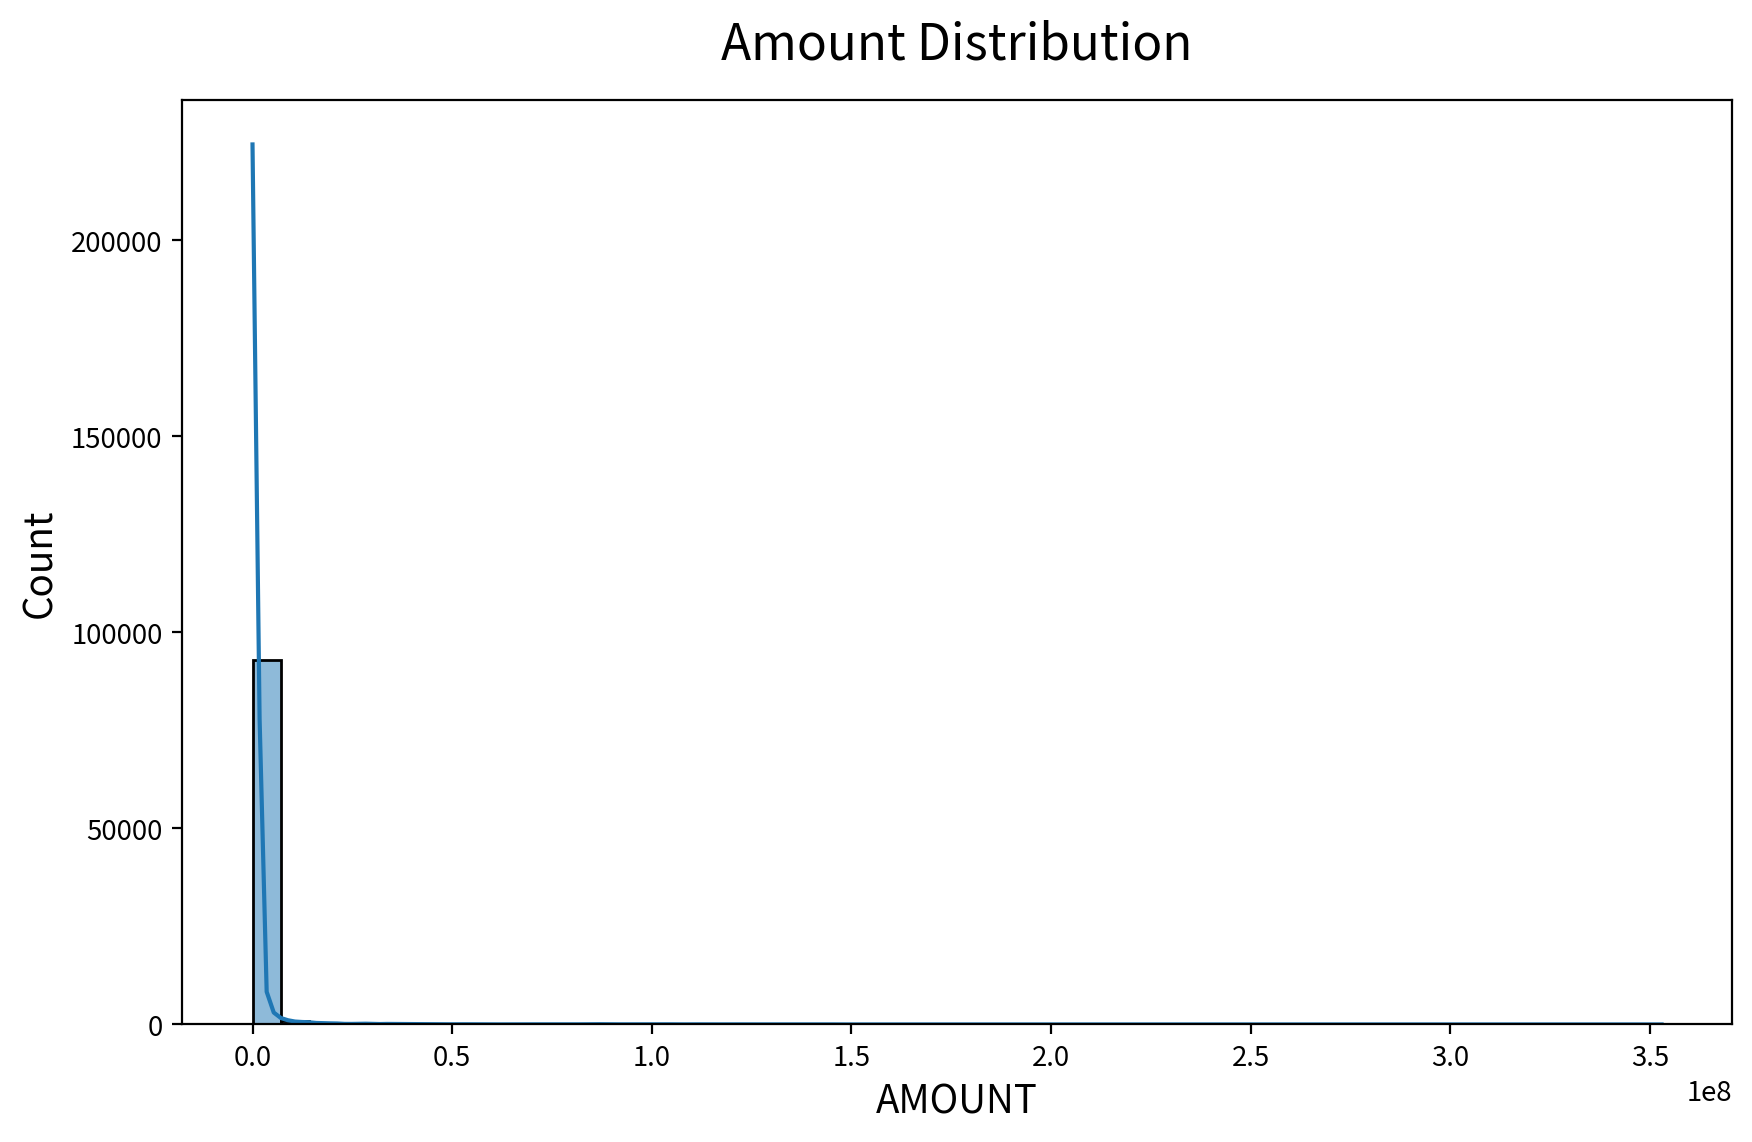

In [114]:
print(df1['AMOUNT'].describe())

import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10,6))
sns.histplot(df1["AMOUNT"], bins=50, kde=True)
plt.title('Amount Distribution')
plt.show()

왜도 (Skewness):$|값| < 0.5$: 대칭에 가까움 (Normal)$0.5 \le |값| < 1$: 약간 치우침 (Moderate)$|값| \ge 1$: 심하게 치우침 (Highly Skewed)첨도 (Kurtosis):$|값| < 1$: 정규분포와 비슷함 (Mesokurtic)$값 \ge 1$: 중앙에 집중되고 꼬리가 두꺼움 (Leptokurtic)$값 \le -1$: 분포가 완만함 (Platykurtic)

### SVC_DESC 변수 value_counts()

In [115]:
df1["SVC_DESC"].value_counts()

SVC_DESC
ICC                            13959
MENTAL_HEALTH_SVCS             11485
CASE_MANAGEMENT/BROKERAGE      10347
MEDICATION_SUPPORT_SVCS         9948
IHBS                            9432
ALL                             9418
CRISIS_INTERVENTION             8406
THERAPEUTIC_BEHAVIORAL_SVCS     7050
CRISIS_STABILIZATION            3210
TFC                             2373
PSYCHIATRIC_HEALTH_FACILITY     2076
CRISIS_RESIDENTIAL_TX_SVCS      1557
SDMC_HOSPITAL_INPATIENT         1546
FULL_DAY_TX_INTENSIVE           1083
SELF_HELP_PEER_SVCS              765
ADULT_RESIDENTIAL_TX_SVCS        693
FULL_DAY_REHAB                   540
BH_PREVENTION_EDUCATION_SVC      507
INPATIENT_ADMIN                  408
MOBILE_CRISIS                    120
Name: count, dtype: int64

In [116]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94923 entries, 0 to 94922
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   RPT_DATE      94923 non-null  object 
 1   RPT_YR        94923 non-null  object 
 2   GEOGRAPHY     94923 non-null  object 
 3   SVC_DESC      94923 non-null  object 
 4   AMOUNT        94923 non-null  float64
 5   AMOUNT_ANNOT  94923 non-null  float64
 6   AMOUNT_TYPE   94903 non-null  object 
dtypes: float64(2), object(5)
memory usage: 5.1+ MB


In [117]:
# inplace=True를 사용하여 바로 칼럼의 이름을 바꾼다
d_1 = df1.copy()

d_1.rename(columns = {"SVC_DESC":"특정 정신건강 서비스"}, inplace=True)

d_1

,RPT_DATE,RPT_YR,GEOGRAPHY,특정 정신건강 서비스,AMOUNT,AMOUNT_ANNOT,AMOUNT_TYPE
0,6/30/2020,FY1920,Alameda,ALL,410.000,0.000,MEMBERS
1,6/30/2020,FY1920,Alameda,ALL,4582253.000,0.000,DOLLARS
2,6/30/2020,FY1920,Alameda,CASE_MANAGEMENT/BROKERAGE,59.000,0.000,MEMBERS
3,6/30/2020,FY1920,Alameda,CASE_MANAGEMENT/BROKERAGE,28843.000,0.000,MINUTES
4,6/30/2020,FY1920,Alameda,CASE_MANAGEMENT/BROKERAGE,67459.000,0.000,DOLLARS
...,...,...,...,...,...,...,...
94918,12/2/2025,FY2425,Yolo,SELF_HELP_PEER_SVCS,0.000,2.000,MINUTES
94919,12/2/2025,FY2425,Yolo,SELF_HELP_PEER_SVCS,0.000,2.000,DOLLARS
94920,12/2/2025,FY2425,Yolo,THERAPEUTIC_BEHAVIORAL_SVCS,0.000,1.000,DOLLARS
94921,12/2/2025,FY2425,Yolo,THERAPEUTIC_BEHAVIORAL_SVCS,0.000,1.000,MEMBERS


### 시계열 분석

### STATE 제거 전

In [118]:
# RPT_DATE를 날짜 형식으로 변환 (이미 하셨다면 통과)
df1['RPT_DATE'] = pd.to_datetime(df1['RPT_DATE'])

# 특정 서비스(예: ICC)의 월별 이용량 추이 추출
time_series = df1[df1['SVC_DESC'] == 'ICC'].set_index('RPT_DATE')
monthly_trend = time_series['AMOUNT'].resample('MS').sum()

In [119]:
df1

,RPT_DATE,RPT_YR,GEOGRAPHY,SVC_DESC,AMOUNT,AMOUNT_ANNOT,AMOUNT_TYPE
0,2020-06-30,FY1920,Alameda,ALL,410.000,0.000,MEMBERS
1,2020-06-30,FY1920,Alameda,ALL,4582253.000,0.000,DOLLARS
2,2020-06-30,FY1920,Alameda,CASE_MANAGEMENT/BROKERAGE,59.000,0.000,MEMBERS
3,2020-06-30,FY1920,Alameda,CASE_MANAGEMENT/BROKERAGE,28843.000,0.000,MINUTES
4,2020-06-30,FY1920,Alameda,CASE_MANAGEMENT/BROKERAGE,67459.000,0.000,DOLLARS
...,...,...,...,...,...,...,...
94918,2025-12-02,FY2425,Yolo,SELF_HELP_PEER_SVCS,0.000,2.000,MINUTES
94919,2025-12-02,FY2425,Yolo,SELF_HELP_PEER_SVCS,0.000,2.000,DOLLARS
94920,2025-12-02,FY2425,Yolo,THERAPEUTIC_BEHAVIORAL_SVCS,0.000,1.000,DOLLARS
94921,2025-12-02,FY2425,Yolo,THERAPEUTIC_BEHAVIORAL_SVCS,0.000,1.000,MEMBERS


### 시각화

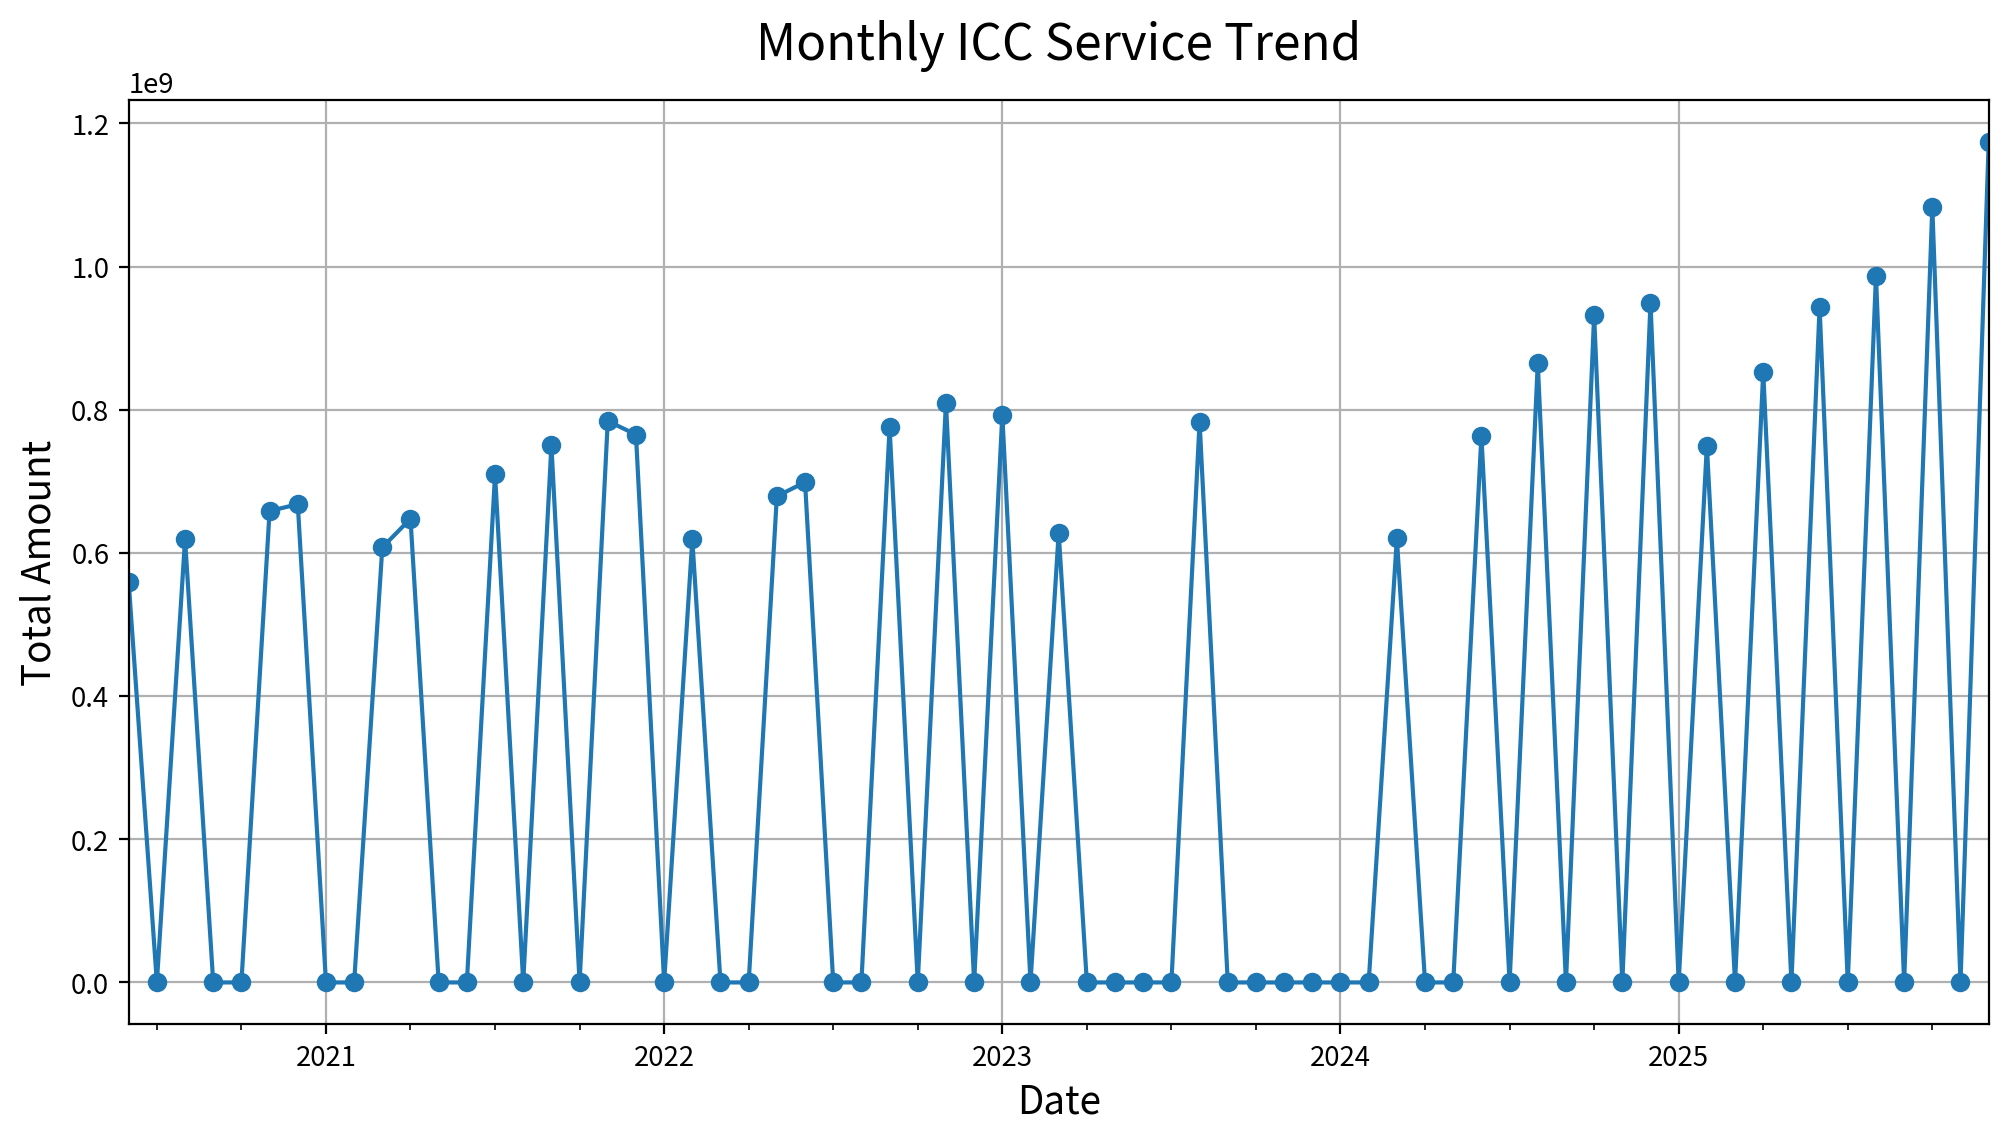

In [120]:
import matplotlib.pyplot as plt

# 그래프 크기 설정
plt.figure(figsize=(12, 6))

# 데이터 플로팅
monthly_trend.plot(marker='o', linestyle='-')

# 제목 및 라벨 추가
plt.title('Monthly ICC Service Trend')
plt.xlabel('Date')
plt.ylabel('Total Amount')
plt.grid(True)

plt.show()

### STATE 제거 후

In [121]:
# RPT_DATE를 날짜 형식으로 변환 (이미 하셨다면 통과)
d_2['RPT_DATE'] = pd.to_datetime(df1['RPT_DATE'])

# 특정 서비스(예: ICC)의 월별 이용량 추이 추출
time_series = d_2[d_2['특정 정신건강 서비스'] == 'ICC'].set_index('RPT_DATE')
monthly_trend = time_series['AMOUNT'].resample('MS').sum()

d_2

,RPT_DATE,RPT_YR,GEOGRAPHY,특정 정신건강 서비스,AMOUNT,AMOUNT_ANNOT,AMOUNT_TYPE
0,2020-06-30,FY1920,Alameda,ALL,410.000,0.000,MEMBERS
1,2020-06-30,FY1920,Alameda,ALL,4582253.000,0.000,DOLLARS
2,2020-06-30,FY1920,Alameda,CASE_MANAGEMENT/BROKERAGE,59.000,0.000,MEMBERS
3,2020-06-30,FY1920,Alameda,CASE_MANAGEMENT/BROKERAGE,28843.000,0.000,MINUTES
4,2020-06-30,FY1920,Alameda,CASE_MANAGEMENT/BROKERAGE,67459.000,0.000,DOLLARS
...,...,...,...,...,...,...,...
94918,2025-12-02,FY2425,Yolo,SELF_HELP_PEER_SVCS,0.000,2.000,MINUTES
94919,2025-12-02,FY2425,Yolo,SELF_HELP_PEER_SVCS,0.000,2.000,DOLLARS
94920,2025-12-02,FY2425,Yolo,THERAPEUTIC_BEHAVIORAL_SVCS,0.000,1.000,DOLLARS
94921,2025-12-02,FY2425,Yolo,THERAPEUTIC_BEHAVIORAL_SVCS,0.000,1.000,MEMBERS


In [122]:
# 1. 제거 전 지역별 합계 (d_1)
summary_before = d_1.groupby("GEOGRAPHY")["AMOUNT"].sum().reset_index()
summary_before.columns = ["GEOGRAPHY", "제거 전 합계"]

# 2. 제거 후 지역별 합계 (d_2)
summary_after = d_2.groupby("GEOGRAPHY")["AMOUNT"].sum().reset_index()
summary_after.columns = ["GEOGRAPHY", "제거 후 합계"]

# 3. 두 데이터프레임 병합 (Left Join)
# 제거 전 데이터에는 'STATE'가 있고 제거 후에는 없으므로, 'how=left'를 사용합니다.
comparison_df = pd.merge(summary_before, summary_after, on="GEOGRAPHY", how="left")

# 4. 결측치 처리 및 차이 열 추가
# 제거 후 데이터에서 'STATE'는 NaN이 되므로 0으로 채워줍니다.
comparison_df["제거 후 합계"] = comparison_df["제거 후 합계"].fillna(0)
comparison_df["차이(Difference)"] = comparison_df["제거 전 합계"] - comparison_df["제거 후 합계"]

# 5. 결과 확인 (차이가 큰 순서대로 나열)
print(comparison_df.sort_values(by="차이(Difference)", ascending=False).head())
comparison_df

    GEOGRAPHY         제거 전 합계        제거 후 합계  차이(Difference)
33      STATE 54717357323.784          0.000 54717357323.784
37  San Diego  1909096027.090 1909095907.090         120.000
0     Alameda   657416388.830  657416388.830           0.000
29     Orange  2459924849.340 2459924849.340           0.000
31     Plumas      897767.000     897767.000           0.000


,GEOGRAPHY,제거 전 합계,제거 후 합계,차이(Difference)
0,Alameda,657416388.830,657416388.830,0.000
1,Alpine,0.000,0.000,0.000
2,Amador,27303829.040,27303829.040,0.000
3,Butte,319377550.860,319377550.860,0.000
4,Calaveras,55923048.010,55923048.010,0.000
5,Colusa,163184.000,163184.000,0.000
6,Contra Costa,1753764794.100,1753764794.100,0.000
7,Del Norte,6522417.000,6522417.000,0.000
8,El Dorado,202393177.340,202393177.340,0.000
9,Fresno,1058152270.490,1058152270.490,0.000


>주요 코드:  .columns<br>

>STATE 제거 전 합계 (d_1): 약 $5.4717 \times 10^{10}$ (약 547억)<br>
>STATE 제거 후 합계 (d_2): $0.0$ (정상적으로 제거됨)<br>
>차이 (Difference): 약 $5.4717 \times 10^{10}$<br>

>결측치가 0인 행들은 데이터 전처리가 훌륭하게 된 칼럼
즉, GEOGRAPHY의 STATE값에만 거대한 값이 포함





### STATE 제거 전, 후에 따른 AMOUNT값의 전체 평균 비교 

In [132]:
import pandas as pd

# 1. STATE가 포함된 데이터(df1)와 제거된 데이터(d_2)의 평균 계산
# numeric_only=True를 사용하여 수치형 컬럼인 AMOUNT에 대해서만 계산합니다.
mean_before = df1['AMOUNT'].mean()
mean_after = d_2['AMOUNT'].mean()

# 2. 결과를 보기 좋게 데이터프레임으로 정리
mean_comparison = pd.DataFrame({
    "분석 대상": ["STATE 제거 전 (df1)", "STATE 제거 후 (d_2)"],
    "AMOUNT 전체 평균": [mean_before, mean_after]
})

# 3. 평균의 차이 계산하여 출력
diff = mean_before - mean_after

print("--- [AMOUNT] 컬럼 전체 평균 비교 ---")
print(mean_comparison)
print(f"\n평균 차이(Difference): {diff:,.2f}")

mean_comparison

--- [AMOUNT] 컬럼 전체 평균 비교 ---
              분석 대상  AMOUNT 전체 평균
0  STATE 제거 전 (df1)   1146041.584
1  STATE 제거 후 (d_2)    597248.925

평균 차이(Difference): 548,792.66


,분석 대상,AMOUNT 전체 평균
0,STATE 제거 전 (df1),1146041.584
1,STATE 제거 후 (d_2),597248.925


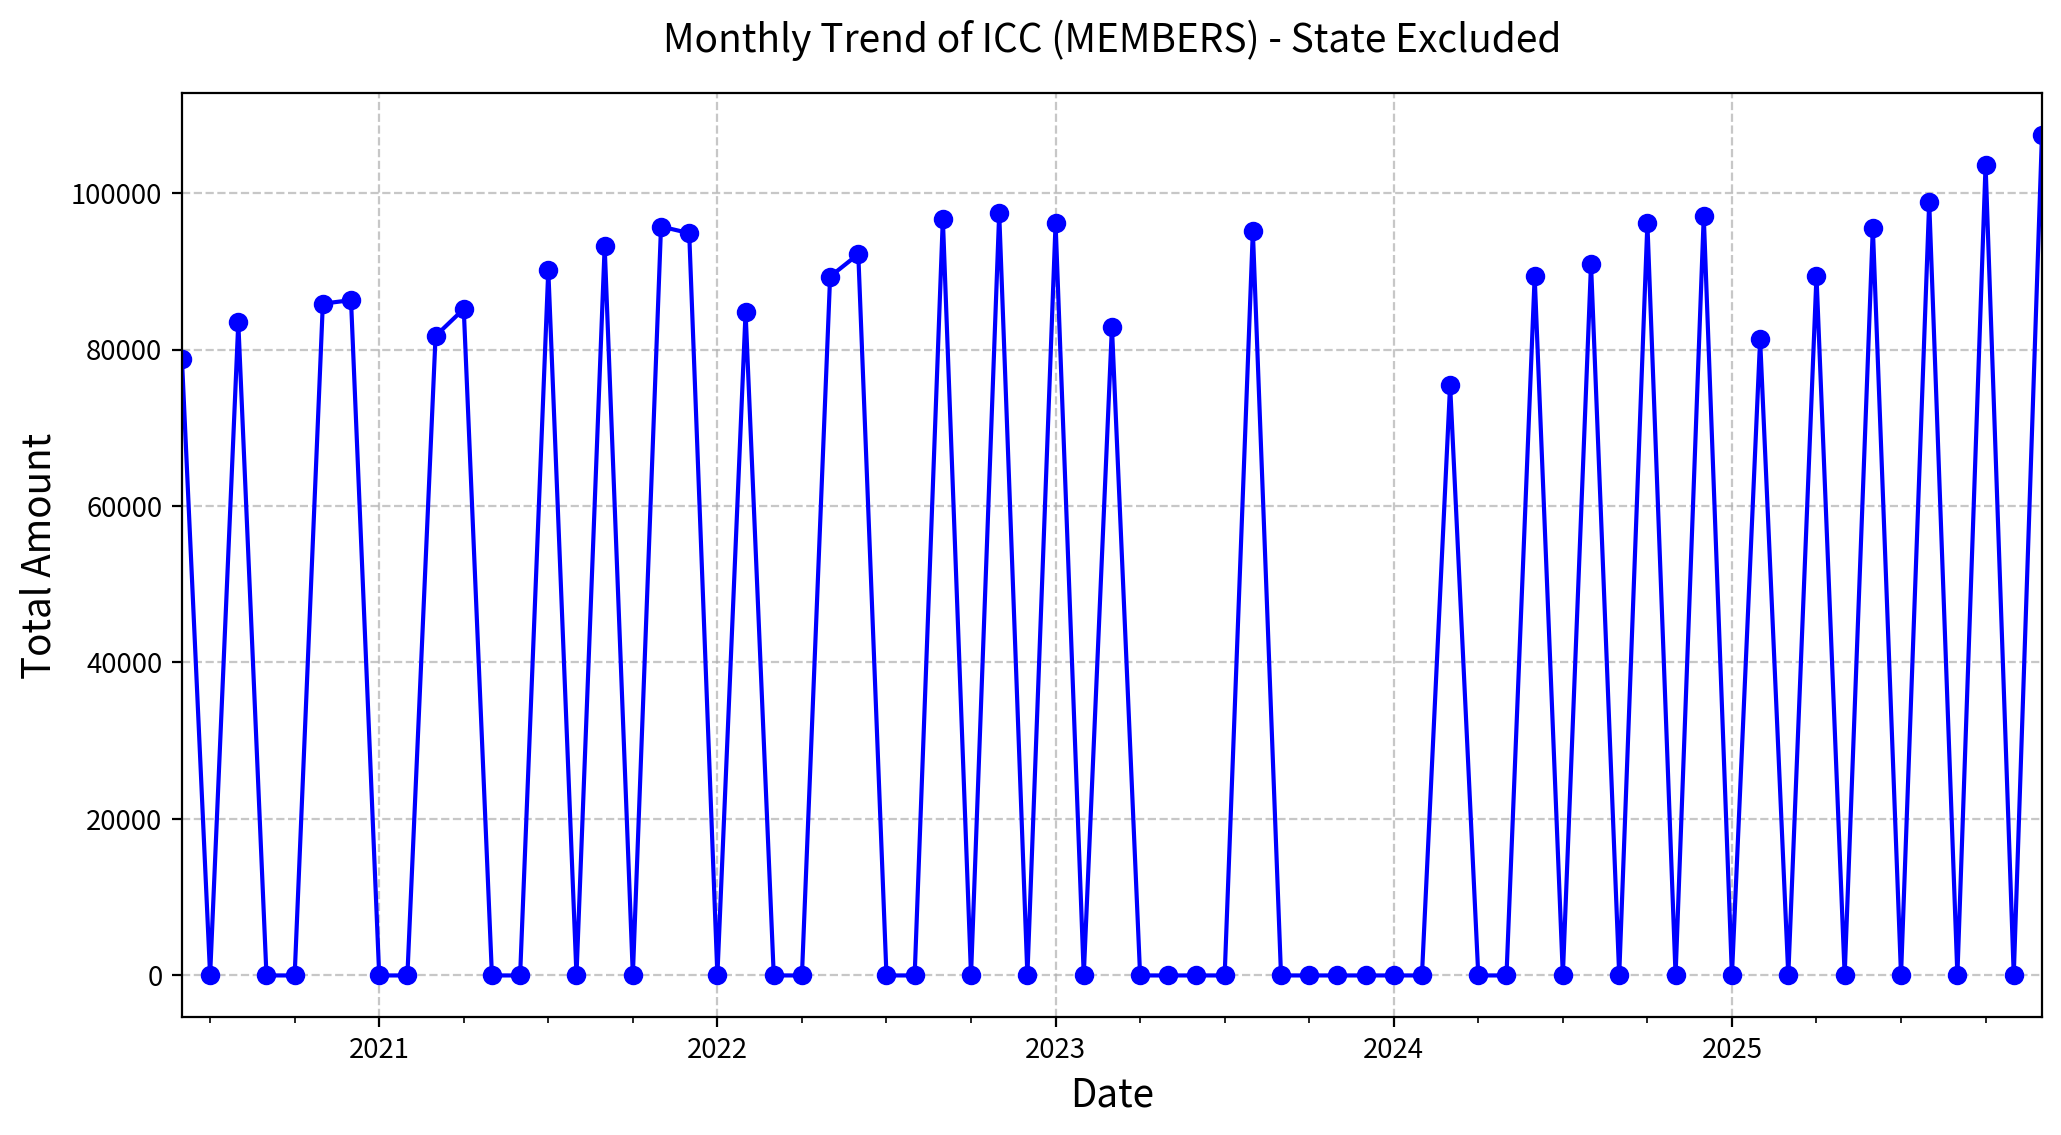

In [124]:
import matplotlib.pyplot as plt

# 1. RPT_DATE를 날짜 형식으로 변환 (d_2에 적용)
d_2['RPT_DATE'] = pd.to_datetime(d_2['RPT_DATE'])

# 2. 특정 서비스(예: ICC)와 특정 단위(예: MEMBERS) 필터링
# 단위를 고정하지 않으면 시간(MINUTES)과 인원(MEMBERS)이 합쳐져 수치가 왜곡될 수 있습니다.
target_service = 'ICC' 
target_type = 'MEMBERS'

filtered_data = d_2[(d_2['특정 정신건강 서비스'] == target_service) & 
                    (d_2['AMOUNT_TYPE'] == target_type)]

# 3. 날짜를 인덱스로 설정하고 월별 합계 계산
monthly_trend = filtered_data.set_index('RPT_DATE')['AMOUNT'].resample('MS').sum()

# 4. 선 그래프 시각화
plt.figure(figsize=(12, 6))
monthly_trend.plot(marker='o', color='b', linestyle='-')

plt.title(f'Monthly Trend of {target_service} ({target_type}) - State Excluded', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Total Amount')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [133]:
d_2

,RPT_DATE,RPT_YR,GEOGRAPHY,특정 정신건강 서비스,AMOUNT,AMOUNT_ANNOT,AMOUNT_TYPE
0,6/30/2020,FY1920,Alameda,ALL,410.000,0.000,MEMBERS
1,6/30/2020,FY1920,Alameda,ALL,4582253.000,0.000,DOLLARS
2,6/30/2020,FY1920,Alameda,CASE_MANAGEMENT/BROKERAGE,59.000,0.000,MEMBERS
3,6/30/2020,FY1920,Alameda,CASE_MANAGEMENT/BROKERAGE,28843.000,0.000,MINUTES
4,6/30/2020,FY1920,Alameda,CASE_MANAGEMENT/BROKERAGE,67459.000,0.000,DOLLARS
...,...,...,...,...,...,...,...
94918,12/2/2025,FY2425,Yolo,SELF_HELP_PEER_SVCS,0.000,2.000,MINUTES
94919,12/2/2025,FY2425,Yolo,SELF_HELP_PEER_SVCS,0.000,2.000,DOLLARS
94920,12/2/2025,FY2425,Yolo,THERAPEUTIC_BEHAVIORAL_SVCS,0.000,1.000,DOLLARS
94921,12/2/2025,FY2425,Yolo,THERAPEUTIC_BEHAVIORAL_SVCS,0.000,1.000,MEMBERS


In [139]:
service_summary = d_2.groupby('특정 정신건강 서비스')[['AMOUNT','AMOUNT_ANNOT']].sum().reset_index()

service_summary = service_summary.sort_values(by="AMOUNT" , ascending = False)

service_summary

# sum()을 사용해야 하는 이유: 현재 데이터셋의 AMOUNT는 서비스 횟수, 이용자 수, 또는 비용 등을 나타내는 수치 데이터입니다.
# 


,특정 정신건강 서비스,AMOUNT,AMOUNT_ANNOT
1,ALL,24069803286.170,972.000
9,ICC,11164948557.510,2385.000
13,MENTAL_HEALTH_SVCS,8256650844.800,2193.000
10,IHBS,7279927115.440,1875.000
19,THERAPEUTIC_BEHAVIORAL_SVCS,1023953780.920,4566.000
12,MEDICATION_SUPPORT_SVCS,814447329.710,4104.000
3,CASE_MANAGEMENT/BROKERAGE,637525167.390,3039.000
6,CRISIS_STABILIZATION,209563913.370,1290.000
4,CRISIS_INTERVENTION,134233315.010,4938.000
7,FULL_DAY_REHAB,106920219.000,234.000


### AMOUNT_TYPE변수 추가

In [141]:
# 서비스명과 단위를 함께 묶어서 AMOUNT와 AMOUNT_ANNOT의 합계 계산
service_type_summary = d_2.groupby(["특정 정신건강 서비스", "AMOUNT_TYPE"])[["AMOUNT", "AMOUNT_ANNOT"]].sum().reset_index()

# 보기 편하게 AMOUNT 기준으로 내림차순 정렬
service_type_summary = service_type_summary.sort_values(by=["특정 정신건강 서비스", "AMOUNT"], ascending=[True, False])

service_type_summary

,특정 정신건강 서비스,AMOUNT_TYPE,AMOUNT,AMOUNT_ANNOT
0,ADULT_RESIDENTIAL_TX_SVCS,DAYS,0.000,147.000
1,ADULT_RESIDENTIAL_TX_SVCS,DOLLARS,0.000,147.000
2,ADULT_RESIDENTIAL_TX_SVCS,MEMBERS,0.000,147.000
3,ALL,DOLLARS,24066666586.170,486.000
4,ALL,MEMBERS,3136700.000,486.000
5,BH_PREVENTION_EDUCATION_SVC,DOLLARS,44032.840,145.000
7,BH_PREVENTION_EDUCATION_SVC,MINUTES,31740.000,145.000
6,BH_PREVENTION_EDUCATION_SVC,MEMBERS,131.000,145.000
8,CASE_MANAGEMENT/BROKERAGE,DOLLARS,505458111.020,1013.000
10,CASE_MANAGEMENT/BROKERAGE,MINUTES,131688925.370,1010.000


### AMOUNT_TYPE 값 중 MEMBERS값 기준으로 GEOGRAPHY 순위

In [144]:
# 1. 'MEMBERS'(이용자 수) 단위만 필터링
members_only = d_2[d_2['AMOUNT_TYPE'] == 'MEMBERS']

# 2. 지역별(GEOGRAPHY)로 이용자 수 합계 계산
geo_member_ranking = members_only.groupby('GEOGRAPHY')['AMOUNT'].sum().reset_index()

# 3. 이용자 수가 많은 순서대로 정렬
geo_member_ranking = geo_member_ranking.sort_values(by='AMOUNT', ascending=False)

# 4. 결과 확인 (상위 10개 지역)
print("--- 캘리포니아 카운티별 이용자 수(MEMBERS) 순위 ---")
geo_member_ranking

# 5. QGIS 활용을 위한 CSV 저장
geo_member_ranking.to_csv("county_members_ranking.csv", index=False)

geo_member_ranking

--- 캘리포니아 카운티별 이용자 수(MEMBERS) 순위 ---


,GEOGRAPHY,AMOUNT
18,Los Angeles,2705419.000
35,San Bernardino,1011860.000
32,Riverside,924273.000
29,Orange,668313.000
33,Sacramento,373421.000
36,San Diego,340329.000
38,San Joaquin,275333.000
14,Kern,242987.000
42,Santa Clara,222667.000
54,Ventura,180772.000


### MEMBERS행에 해당하는 항목 
실제로 몇 명의 아이들이 이 서비스를 받았는가

In [ ]:
# 'AMOUNT_TYPE' 컬럼의 값이 'MEMBERS'인 행만 추출
service_members_only = service_type_summary[service_type_summary['AMOUNT_TYPE']=='MEMBERS']

# 이용자 수가 많은 순서대로 정렬 (선택 사항)
service_members_only = service_members_only.sort_values(by='AMOUNT', ascending=False) 

# 결과 확인
print("--- 특정 정신건강 서비스별 이용자 수(MEMBERS) 현황 ---")
service_members_only

--- 특정 정신건강 서비스별 이용자 수(MEMBERS) 현황 ---


,특정 정신건강 서비스,AMOUNT_TYPE,AMOUNT,AMOUNT_ANNOT
4,ALL,MEMBERS,3136700.000,486.000
27,ICC,MEMBERS,2635321.000,795.000
30,IHBS,MEMBERS,956146.000,625.000
39,MENTAL_HEALTH_SVCS,MEMBERS,948020.000,731.000
9,CASE_MANAGEMENT/BROKERAGE,MEMBERS,378131.000,1013.000
36,MEDICATION_SUPPORT_SVCS,MEMBERS,352002.000,1368.000
19,CRISIS_STABILIZATION,MEMBERS,88223.000,430.000
12,CRISIS_INTERVENTION,MEMBERS,79883.000,1646.000
58,THERAPEUTIC_BEHAVIORAL_SVCS,MEMBERS,61545.000,1522.000
52,SELF_HELP_PEER_SVCS,MEMBERS,11820.000,162.000


In [152]:
d_2['AMOUNT'].describe()

count       90529.000
mean       597248.925
std       4529922.614
min             0.000
25%             0.000
50%           179.000
75%         90003.920
max     144094010.000
Name: AMOUNT, dtype: float64

In [149]:
d_2['AMOUNT_TYPE'].describe()

count       90519
unique          5
top       MEMBERS
freq        31714
Name: AMOUNT_TYPE, dtype: object

> AMOUNT_TYPE 컬럼에 describe()를 적용했을 때 수치가 아닌 count, unique, top, freq 같은 값이 나오는 이유는 이 컬럼이 숫자가 아닌 문자열(범주형/Object) 데이터이기 때문입니다.

> 판다스의 describe() 함수는 데이터의 타입에 따라 다른 결과를 보여줍니다.

1. 결과값의 의미 해석
출력된 결과의 각 항목은 다음과 같은 의미를 담고 있습니다.

count: 결측치를 제외한 전체 행의 개수입니다.

unique: 중복을 제거한 항목의 종류 수입니다. (예: MEMBERS, MINUTES, DOLLARS 등 총 4~5종류가 있다면 '4' 또는 '5'로 표시됩니다.)

top: 데이터에서 가장 많이 등장한 항목 이름입니다.

freq: 'top' 항목이 전체 데이터에서 몇 번이나 등장했는지 나타내는 빈도수입니다.

----------------------------------------------------------------------------
AMOUNT (약264만): 이 수치는 해당 기간 동안 집계된 전체 서비스량(인원, 시간 등)의 총합입니다. 200만이 넘는 수치는 매우 큰 규모를 나타냅니다.

AMOUNT_ANNOT (795): 이 수치는 '개인정보 보호를 위해 실제 값을 숨긴(Masking) 횟수'의 총합입니다.

수치적 비중: 260만이라는 거대한 AMOUNT에 비해 AMOUNT_ANNOT은 고작 795에 불과합니다. 이는 전체 데이터 중 극히 일부(약 0.03%)만 보안 처리가 되었다는 뜻입니다.

---------------------------------------------------------------------------

AMOUNT: 5,000 (매우 낮음)

AMOUNT_ANNOT: 4,500 (매우 높음)

해석: 이 서비스는 보고되는 거의 모든 케이스가 11명 미만이라서 실제 숫자가 다 가려지고 AMOUNT_ANNOT 점수만 쌓인 것입니다. 데이터상으로는 작아 보이지만, 실제로는 아주 소수의 아이들에게만 제공되는 고도로 특수화된 서비스임을 시사합니다.

 - 어떤 값이 가장 영향을 많이 미칠까...?
 AMOUNT

### 

목표선정<br>
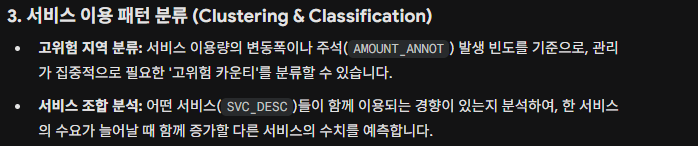